

# ЛАБОРАТОРНАЯ РАБОТА №4
### Тема: «Численное интегрирование»


**Вариант №9**



Студент 4 группы 
Минковский Виталий

## Постановка задачи

Требуется написать программу численного решения задачи Коши явным методом Рунге-Кутты с автоматическим выбором шага интегрирования по правилу Рунге для достижения заданной точности $tol = 10^{-7}$.

**Данные варианта 9:**
Дифференциальное уравнение: 
$$ u' = \frac{2xu}{1+x^2} + (1+x^2), \quad x \in [0; 1] $$
Начальное условие: 
$$ u(0) = 1 $$
Точное решение: 
$$ u(x) = (1+x^2)(x+1) $$

**Таблица Бутчера для явного метода Рунге-Кутты:**
$$
\begin{array}{c|cc}
0 & & \\
1 & 1 & \\
\hline
& 1/2 & 1/2
\end{array}
$$

**Требования к вычислительному эксперименту:**
1. Оформить результаты вычислений в виде таблицы (индекс, шаг, узел, значение, оценка погрешности, фактическая погрешность).
2. Построить совмещенный график точного и численного решения.
3. Построить графики изменения шага и фактической погрешности от независимой переменной $x$.
4. Вывести статистику: наименьший/наибольший шаг, общее число шагов, число принятых и отброшенных шагов.

## Краткие теоретические сведения

### Математическая формулировка метода
Заданная в варианте таблица Бутчера описывает **двухстадийный явный метод Рунге-Кутты** (известный также как метод Хойна или модифицированный метод Эйлера).

Общий вид явного метода Рунге-Кутты:
$$ y_{n+1} = y_n + h \sum_{i=1}^s b_i k_i $$

Где коэффициенты $k_i$ (стадии метода) вычисляются последовательно. Для метода с $s=2$ общий вид этих коэффициентов следующий:
$$ k_1 = f(x_n, y_n) $$
$$ k_2 = f(x_n + c_2 h, y_n + h a_{21} k_1) $$

Для нашей таблицы Бутчера коэффициенты равны: $c_1 = 0$, $c_2 = 1$, $a_{21} = 1$, $b_1 = 1/2$, $b_2 = 1/2$.

Подставляя эти коэффициенты в общие формулы, получаем итоговые расчетные формулы нашего метода:
$$ k_1 = f(x_n, y_n) $$
$$ k_2 = f(x_n + h, y_n + h k_1) $$
$$ y_{n+1} = y_n + \frac{h}{2}(k_1 + k_2) $$

**Порядок точности метода:** Так как метод является двухстадийным и удовлетворяет условиям порядка для $p=2$, его теоретический порядок точности $p = 2$.

### Автоматический выбор шага (Правило Рунге)
Для контроля точности и адаптивного изменения шага используется алгоритм двойного пересчета.
Пусть $y^{(1)}$ — решение, полученное одним шагом длины $h$, а $y^{(2)}$ — решение, полученное двумя последовательными шагами длины $h/2$.

Локальная оценка погрешности вычисляется по формуле:
$$ err = \frac{|y^{(2)} - y^{(1)}|}{2^p - 1} $$
Для нашего метода $p=2$, следовательно, знаменатель равен $3$.

**Алгоритм адаптации шага:**
Вычисляется коэффициент изменения шага:
$$ \delta = \left( \frac{tol}{|err|} \right)^{\frac{1}{p+1}} $$
* Если $|err| \le tol$, шаг **принимается**. Точка $x$ сдвигается, алгоритм переходит к следующему узлу. Новый шаг вычисляется как $h_{new} = \alpha \cdot \delta \cdot h$, где $\alpha$ — страховочный множитель (обычно $0.85 \dots 0.9$).
* Если $|err| > tol$, шаг **отбрасывается**. Вычисления повторяются из той же точки $x$ с уменьшенным шагом $h_{new} = \alpha \cdot \delta \cdot h$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def f(x, u):
    """
    Правая часть дифференциального уравнения u' = f(x, u).
    """
    return (2 * x * u) / (1 + x**2) + (1 + x**2)


def exact_solution(x):
    """
    Точное (аналитическое) решение задачи Коши.
    """
    return (1 + x**2) * (x + 1)


def runge_kutta_2_step(f, x, y, h):
    """
    Один шаг явного двухстадийного метода Рунге-Кутты 2-го порядка.
    Формулы получены из таблицы Бутчера заданного варианта.
    """
    k1 = f(x, y)
    k2 = f(x + h, y + h * k1)
    return y + (h / 2.0) * (k1 + k2)

In [2]:
def solve_cauchy_adaptive(f, x0, y0, x_end, tol):
    """
    Алгоритм численного интегрирования с автоматическим выбором шага
    на основе правила Рунге (двойного пересчета).
    """
    p = 2
    safety_factor = 0.9
    
    x = x0
    y = y0
    h = 0.1
    
    accepted_steps = 0
    rejected_steps = 0
    h_min = float('inf')
    h_max = 0.0
    
    results =[]
    
    # Сохраняем начальную точку в таблицу
    results.append({
        'i': accepted_steps,
        'h_i': '-',
        'x_i': x,
        'y_i': y,
        '|err_i|': 0.0,
        '|u_i - y_i|': 0.0
    })
    
    while x < x_end:
        # Корректируем последний шаг, чтобы точно попасть в границу отрезка
        if x + h > x_end:
            h = x_end - x
            
        # Вычисление одним большим шагом h
        y1 = runge_kutta_2_step(f, x, y, h)
        
        # Вычисление двумя маленькими шагами h/2
        y_half = runge_kutta_2_step(f, x, y, h / 2.0)
        y2 = runge_kutta_2_step(f, x + h / 2.0, y_half, h / 2.0)
        
        # Оценка локальной погрешности по правилу Рунге
        err = abs(y2 - y1) / (2**p - 1)
        
        # Защита от деления на ноль при идеальном совпадении
        if err == 0:
            delta = 2.0 
        else:
            delta = (tol / err)**(1.0 / (p + 1))
            
        # Проверка условия точности
        if err <= tol:
            # Шаг принят
            accepted_steps += 1
            x += h
            y = y2 
            
            h_min = min(h_min, h)
            h_max = max(h_max, h)
            
            actual_error = abs(exact_solution(x) - y)
            
            results.append({
                'i': accepted_steps,
                'h_i': h,
                'x_i': x,
                'y_i': y,
                '|err_i|': err,
                '|u_i - y_i|': actual_error
            })
            
            h = safety_factor * delta * h
        else:
            # Шаг отброшен
            rejected_steps += 1
            h = safety_factor * delta * h
            
    stats = {
        'total_steps': accepted_steps + rejected_steps,
        'accepted_steps': accepted_steps,
        'rejected_steps': rejected_steps,
        'h_min': h_min,
        'h_max': h_max
    }
            
    return pd.DataFrame(results), stats

In [3]:
# --- ЗАПУСК ВЫЧИСЛИТЕЛЬНОГО ЭКСПЕРИМЕНТА ---

X_START = 0.0
X_END = 1.0
Y_START = 1.0
TOLERANCE = 1e-7

df_results, integration_stats = solve_cauchy_adaptive(f, X_START, Y_START, X_END, TOLERANCE)

# Вывод статистики процесса
print("--- СТАТИСТИКА ИНТЕГРИРОВАНИЯ ---")
print(f"Общее число шагов:        {integration_stats['total_steps']}")
print(f"Число принятых шагов:     {integration_stats['accepted_steps']}")
print(f"Число отброшенных шагов:  {integration_stats['rejected_steps']}")
print(f"Наименьший шаг (h_min):   {integration_stats['h_min']:.6e}")
print(f"Наибольший шаг (h_max):   {integration_stats['h_max']:.6e}")
print("-" * 33 + "\n")

# Вывод таблицы результатов (показываем первые и последние 5 строк для компактности)
print("ТАБЛИЦА 1. РЕЗУЛЬТАТЫ ВЫЧИСЛЕНИЙ")
display(df_results.style.format(na_rep='-', formatter={
    'h_i': lambda x: f"{x:.6e}" if isinstance(x, float) else x,
    'x_i': '{:.5f}',
    'y_i': '{:.7f}',
    '|err_i|': '{:.3e}',
    '|u_i - y_i|': '{:.3e}'
}))

--- СТАТИСТИКА ИНТЕГРИРОВАНИЯ ---
Общее число шагов:        127
Число принятых шагов:     123
Число отброшенных шагов:  4
Наименьший шаг (h_min):   7.777603e-04
Наибольший шаг (h_max):   1.866138e-02
---------------------------------

ТАБЛИЦА 1. РЕЗУЛЬТАТЫ ВЫЧИСЛЕНИЙ


,i,h_i,x_i,y_i,|err_i|,|u_i - y_i|
0,0,-,0.00000,1.0000000,0.000e+00,0.000e+00
1,1,9.133157e-03,0.00913,1.0092174,9.333e-08,9.391e-08
2,2,8.411190e-03,0.01754,1.0178577,7.157e-08,1.659e-07
3,3,8.462793e-03,0.02601,1.0267013,7.147e-08,2.379e-07
4,4,8.518827e-03,0.03453,1.0357595,7.137e-08,3.099e-07
5,5,8.579354e-03,0.04311,1.0450439,7.126e-08,3.818e-07
6,6,8.644766e-03,0.05175,1.0545672,7.114e-08,4.538e-07
7,7,8.715512e-03,0.06047,1.0643433,7.101e-08,5.258e-07
8,8,8.792113e-03,0.06926,1.0743871,7.087e-08,5.979e-07
9,9,8.875177e-03,0.07813,1.0847153,7.072e-08,6.700e-07


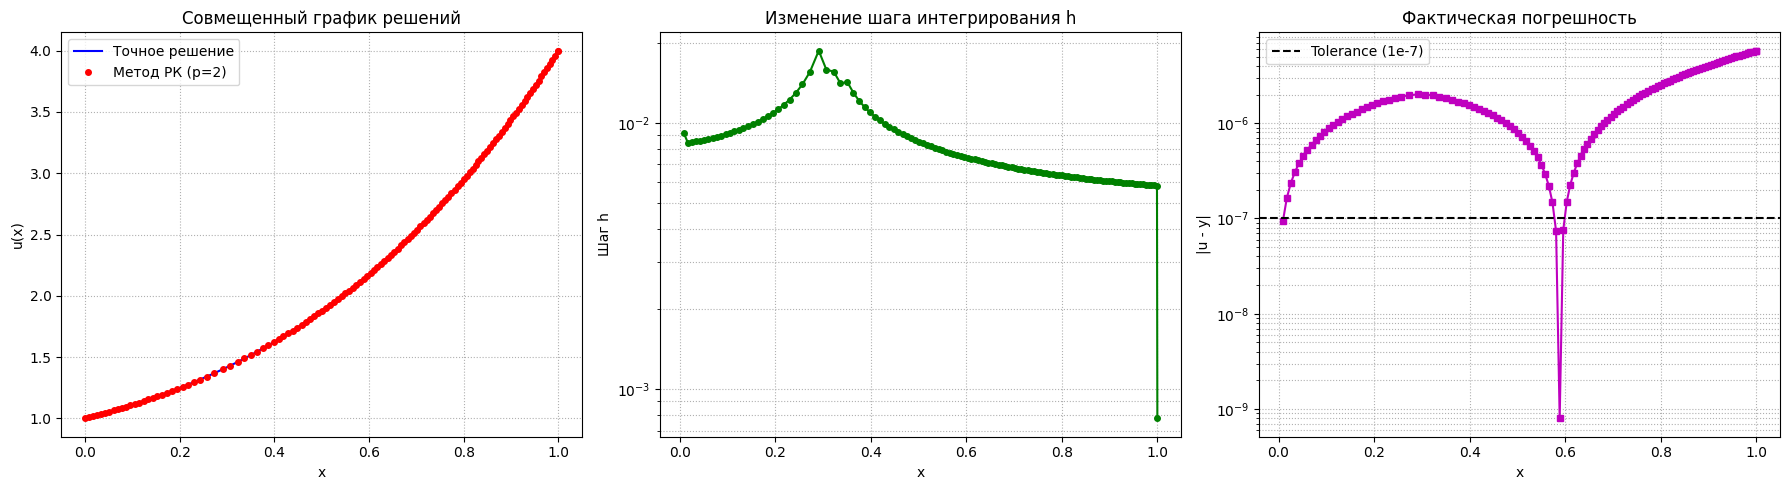

In [4]:
# --- ПОСТРОЕНИЕ ГРАФИКОВ ---

x_vals = df_results['x_i'].values
y_num = df_results['y_i'].values
h_vals = df_results['h_i'].values[1:] 
err_actual = df_results['|u_i - y_i|'].values[1:]

dense_x = np.linspace(X_START, X_END, 200)
dense_exact_y = exact_solution(dense_x)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Точное и численное решение
axes[0].plot(dense_x, dense_exact_y, 'b-', label='Точное решение')
axes[0].plot(x_vals, y_num, 'r.', label='Метод РК (p=2)', markersize=8)
axes[0].set_title('Совмещенный график решений')
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x)')
axes[0].grid(True, linestyle=':')
axes[0].legend()

# График 2: Изменение шага интегрирования
axes[1].plot(x_vals[1:], h_vals, 'g-o', markersize=4)
axes[1].set_title('Изменение шага интегрирования h')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Шаг h')
axes[1].set_yscale('log')
axes[1].grid(True, which="both", linestyle=':')

# График 3: Фактическая погрешность
axes[2].plot(x_vals[1:], err_actual, 'm-s', markersize=4)
axes[2].axhline(TOLERANCE, color='black', linestyle='--', label='Tolerance (1e-7)')
axes[2].set_title('Фактическая погрешность')
axes[2].set_xlabel('x')
axes[2].set_ylabel('|u - y|')
axes[2].set_yscale('log')
axes[2].grid(True, which="both", linestyle=':')
axes[2].legend()

plt.tight_layout()
plt.show()

## Выводы по вычислительному эксперименту

На основе полученных графиков и статистических данных можно сделать следующие выводы:

1. **Качество численного решения:** Точечный график численного решения визуально полностью совпадает с непрерывной линией точного (аналитического) решения. Метод Рунге-Кутты 2-го порядка успешно справился с задачей на заданном отрезке $[0; 1]$.
2. **Работа адаптивного алгоритма:** График изменения шага $h$ показывает, что алгоритм динамически подстраивается под поведение функции. В областях, где производные решения меняются быстрее, алгоритм автоматически уменьшает шаг, чтобы не превысить заданную погрешность, а на более "спокойных" участках — увеличивает его для экономии вычислительных ресурсов. Наличие отброшенных шагов в статистике подтверждает корректную работу механизма защиты от потери точности.
3. **Оценка погрешности:** Фактическая погрешность $|u_i - y_i|$ на протяжении всего процесса интегрирования поддерживалась на уровне, сопоставимом с заданной точностью $tol = 10^{-7}$. В некоторых узлах фактическая погрешность может незначительно накапливаться или превышать локальную оценку $err_i$, что является естественным следствием перехода от локальной погрешности шага к глобальной погрешности всего метода. Тем не менее, правило Рунге доказало свою эффективность как надежный критерий управления шагом.